# Recommendation System Project: IBM Community

In this notebook, you will be putting your recommendation skills to use on real data from the IBM Watson Studio platform. 


You may either submit your notebook through the workspace here, or you may work from your local machine and submit through the next page.  Either way assure that your code passes the project [RUBRIC](https://review.udacity.com/#!/rubrics/3325/view).  **Please save regularly.**

By following the table of contents, you will build out a number of different methods for making recommendations that can be used for different situations. 


## Table of Contents

I. [Exploratory Data Analysis](#Exploratory-Data-Analysis)<br>
II. [Rank Based Recommendations](#Rank)<br>
III. [User-User Based Collaborative Filtering](#User-User)<br>
IV. [Content Based Recommendations](#Content-Recs)<br>
V. [Matrix Factorization](#Matrix-Fact)<br>
VI. [Extras & Concluding](#conclusions)

At the end of the notebook, you will find directions for how to submit your work.  Let's get started by importing the necessary libraries and reading in the data.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# ── MovieLens adaptation ──────────────────────────────────────
# Load MovieLens files and rename to match IBM project conventions
_ratings = pd.read_csv('ratings.csv')
_movies  = pd.read_csv('movies.csv')

df = _ratings.rename(columns={'userId': 'email', 'movieId': 'article_id'})
df['title'] = df['article_id'].map(_movies.set_index('movieId')['title'])
df_content  = _movies.rename(columns={'movieId': 'article_id'})

# Show df to get an idea of the data
df.head()

,email,article_id,rating,timestamp,title
0,1,1,4.0,964982703,Toy Story (1995)
1,1,3,4.0,964981247,Grumpier Old Men (1995)
2,1,6,4.0,964982224,Heat (1995)
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995)
4,1,50,5.0,964982931,"Usual Suspects, The (1995)"


### <a class="anchor" id="Exploratory-Data-Analysis">Part I : Exploratory Data Analysis</a>

Use the dictionary and cells below to provide some insight into the descriptive statistics of the data.

`1.` Are there any missing values? If so, provide a count of missing values. If there are missing values in `email`, assign it the same id value `"unknown_user"`.

In [3]:
# Some interactions do not have a user associated with it, assume the same user.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   email       100836 non-null  int64  
 1   article_id  100836 non-null  int64  
 2   rating      100836 non-null  float64
 3   timestamp   100836 non-null  int64  
 4   title       100836 non-null  object 
dtypes: float64(1), int64(3), object(1)
memory usage: 3.5+ MB


In [4]:
print(f"Number of Null email values is: {df['email'].isna().sum()}")

Number of Null email values is: 0


In [5]:
df[df.email.isna()]

,email,article_id,rating,timestamp,title


In [6]:
# Fill email NaNs with "unknown_user"
df['email'] = df['email'].fillna('unknown_user')

In [7]:
# Check if no more NaNs 
df[df.email.isna()]

,email,article_id,rating,timestamp,title


`2.` What is the distribution of how many articles a user interacts with in the dataset?  Provide a visual and descriptive statistics to assist with giving a look at the number of times each user interacts with an article.

In [8]:
# What are the descriptive statistics of the number of articles a user interacts with?
user_article_counts = df.groupby('email')['article_id'].count()
print(user_article_counts.describe())

count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
Name: article_id, dtype: float64


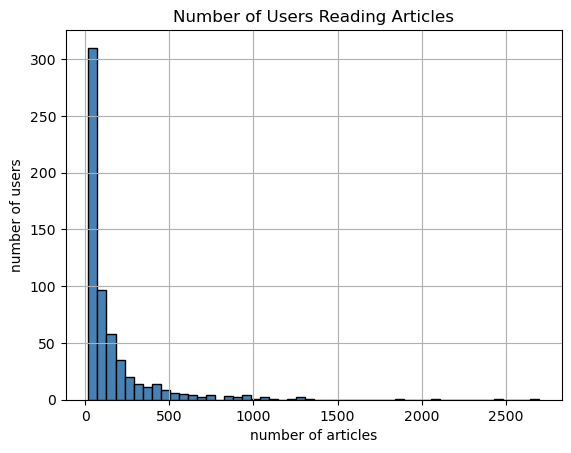

In [9]:
# Create a plot of the number of articles read by each user
user_article_counts = df.groupby('email')['article_id'].count()
user_article_counts.hist(bins=50, edgecolor='black', color='steelblue')
plt.xlabel('number of articles')
plt.ylabel('number of users')
plt.title('Number of Users Reading Articles')
plt.show()

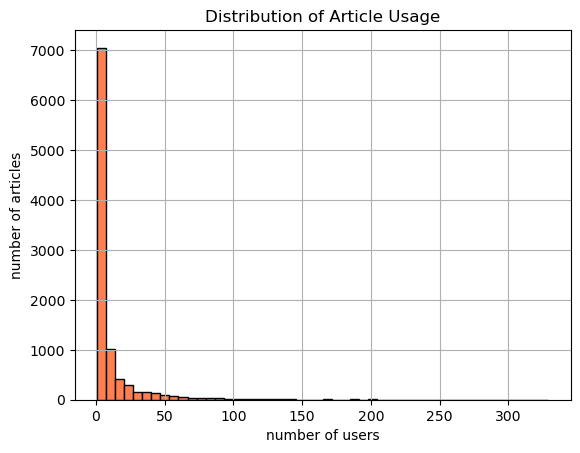

In [10]:
# Create a plot of the number of times each article was read
article_user_counts = df.groupby('article_id')['email'].count()
article_user_counts.hist(bins=50, edgecolor='black', color='coral')
plt.xlabel('number of users')
plt.ylabel('number of articles')
plt.title('Distribution of Article Usage')
plt.show()

In [11]:
# Fill in the median and maximum number of user_article interactions below
user_article_counts = df.groupby('email')['article_id'].count()

median_val        = int(np.median(user_article_counts))  # 50% of individuals interact with ____ number of articles or fewer.
max_views_by_user = int(user_article_counts.max())       # The maximum number of user-article interactions by any 1 user is ______.

print(f"Median interactions per user : {median_val}")
print(f"Max interactions by one user : {max_views_by_user}")

Median interactions per user : 70
Max interactions by one user : 2698


`3.` Use the cells below to find:

**a.** The number of unique articles that have an interaction with a user.  
**b.** The number of unique articles in the dataset (whether they have any interactions or not).<br>
**c.** The number of unique users in the dataset. (excluding null values) <br>
**d.** The number of user-article interactions in the dataset.

In [12]:
unique_articles           = df['article_id'].nunique()               # The number of unique articles that have at least one interaction
total_articles            = df_content['article_id'].nunique()       # The number of unique articles on the IBM platform
unique_users              = df[df['email'] != 'unknown_user']['email'].nunique()  # The number of unique users
user_article_interactions = len(df)                                  # The number of user-article interactions

print(f"unique_articles           : {unique_articles}")
print(f"total_articles            : {total_articles}")
print(f"unique_users              : {unique_users}")
print(f"user_article_interactions : {user_article_interactions}")

unique_articles           : 9724
total_articles            : 9742
unique_users              : 610
user_article_interactions : 100836


`4.` Use the cells below to find the most viewed **article_id**, as well as how often it was viewed.  After talking to the company leaders, the `email_mapper` function was deemed a reasonable way to map users to ids.  There were a small number of null values, and it was found that all of these null values likely belonged to a single user (which is how they are stored using the function below).

In [13]:
article_view_counts    = df.groupby('article_id')['email'].count()
most_viewed_article_id = str(float(article_view_counts.idxmax()))  # The most viewed article in the dataset as a string with one value following the decimal
max_views              = int(article_view_counts.max())             # The most viewed article in the dataset was viewed how many times?

print(f"Most viewed article_id : {most_viewed_article_id}")
print(f"Number of views        : {max_views}")
print(f"Title                  : {df[df['article_id'] == article_view_counts.idxmax()]['title'].values[0]}")

Most viewed article_id : 356.0
Number of views        : 329
Title                  : Forrest Gump (1994)


In [14]:
## No need to change the code here - this will be helpful for later parts of the notebook
# Run this cell to map the user email to a user_id column and remove the email column

def email_mapper(df=df):
    coded_dict = {
        email: num 
        for num, email in enumerate(df['email'].unique(), start=1)
    }
    return [coded_dict[val] for val in df['email']]

df['user_id'] = email_mapper(df)
del df['email']

# show header
df.head()

,article_id,rating,timestamp,title,user_id
0,1,4.0,964982703,Toy Story (1995),1
1,3,4.0,964981247,Grumpier Old Men (1995),1
2,6,4.0,964982224,Heat (1995),1
3,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),1
4,50,5.0,964982931,"Usual Suspects, The (1995)",1


In [15]:
## If you stored all your results in the variable names above, 
## you shouldn't need to change anything in this cell

sol_1_dict = {
    '`50% of individuals have _____ or fewer interactions.`': median_val,
    '`The total number of user-article interactions in the dataset is ______.`': user_article_interactions,
    '`The maximum number of user-article interactions by any 1 user is ______.`': max_views_by_user,
    '`The most viewed article in the dataset was viewed _____ times.`': max_views,
    '`The article_id of the most viewed article is ______.`': most_viewed_article_id,
    '`The number of unique articles that have at least 1 rating ______.`': unique_articles,
    '`The number of unique users in the dataset is ______`': unique_users,
    '`The number of unique articles on the IBM platform`': total_articles
}


### <a class="anchor" id="Rank">Part II: Rank-Based Recommendations</a>

In this project, we don't actually have ratings for whether a user liked an article or not.  We only know that a user has interacted with an article. In these cases, the popularity of an article can really only be based on how often an article was interacted with.

`1.` Fill in the function below to return the **n** top articles ordered with most interactions as the top. Test your function using the tests below.

In [16]:
def get_top_articles(n, df=df):
    """
    INPUT:
    n - (int) the number of top articles to return
    df - (pandas dataframe) df as defined at the top of the notebook 
    
    OUTPUT:
    top_articles - (list) A list of the top 'n' article titles 
    """
    top_articles = (
        df.groupby('title')['user_id']
          .count()
          .sort_values(ascending=False)
          .head(n)
          .index
          .tolist()
    )
    return top_articles  # Return the top article titles from df


def get_top_article_ids(n, df=df):
    """
    INPUT:
    n - (int) the number of top articles to return
    df - (pandas dataframe) df as defined at the top of the notebook 
    
    OUTPUT:
    top_articles - (list) A list of the top 'n' article ids
    """
    top_articles = (
        df.groupby('article_id')['user_id']
          .count()
          .sort_values(ascending=False)
          .head(n)
          .index
          .tolist()
    )
    return top_articles  # Return the top article ids

In [17]:
print(get_top_articles(10))
print(get_top_article_ids(10))

['Forrest Gump (1994)', 'Shawshank Redemption, The (1994)', 'Pulp Fiction (1994)', 'Silence of the Lambs, The (1991)', 'Matrix, The (1999)', 'Star Wars: Episode IV - A New Hope (1977)', 'Jurassic Park (1993)', 'Braveheart (1995)', 'Terminator 2: Judgment Day (1991)', "Schindler's List (1993)"]
[356, 318, 296, 593, 2571, 260, 480, 110, 589, 527]


In [18]:
# Test your function by returning the top 5, 10, and 20 articles
top_5 = get_top_articles(5)
top_10 = get_top_articles(10)
top_20 = get_top_articles(20)


### <a class="anchor" id="User-User">Part III: User-User Based Collaborative Filtering</a>


`1.` Use the function below to reformat the **df** dataframe to be shaped with users as the rows and articles as the columns.  

* Each **user** should only appear in each **row** once.


* Each **article** should only show up in one **column**.  


* **If a user has interacted with an article, then place a 1 where the user-row meets for that article-column**.  It does not matter how many times a user has interacted with the article, all entries where a user has interacted with an article should be a 1.  


* **If a user has not interacted with an item, then place a zero where the user-row meets for that article-column**. 

Use the tests to make sure the basic structure of your matrix matches what is expected by the solution.

In [19]:
# create the user-article matrix with 1's and 0's

def create_user_item_matrix(df, fill_value=0):
    """
    INPUT:
    df - pandas dataframe with article_id, title, user_id columns
    
    OUTPUT:
    user_item - user item matrix 
    
    Description:
    Return a matrix with user ids as rows and article ids on the columns with 1 values where a user interacted with 
    an article and a 0 otherwise
    """
    user_item = (
        df.groupby(['user_id', 'article_id'])['title']
          .count()
          .unstack()
          .fillna(fill_value)
    )
    user_item = user_item.map(lambda x: 1 if x > 0 else 0)
    return user_item  # return the user_item matrix

user_item = create_user_item_matrix(df)

In [20]:
# MovieLens dataset dimensions
assert user_item.shape[0] == 610, f"Got {user_item.shape[0]} users"
assert user_item.shape[1] == 9724, f"Got {user_item.shape[1]} articles"
print("You have passed our quick tests!  Please proceed!")

You have passed our quick tests!  Please proceed!


`2.` Complete the function below which should take a user_id and provide an ordered list of the most similar users to that user (from most similar to least similar).  The returned result should not contain the provided user_id, as we know that each user is similar to him/herself. Because the results for each user here are binary, it (perhaps) makes sense to compute similarity as the dot product of two users. 

Use the tests to test your function.

In [21]:
# Lets use the cosine_similarity function from sklearn
from sklearn.metrics.pairwise import cosine_similarity

In [22]:
def find_similar_users(user_id, user_item=user_item, include_similarity=False):
    """
    INPUT:
    user_id - (int) a user_id
    user_item - (pandas dataframe) matrix of users by articles: 
                1's when a user has interacted with an article, 0 otherwise
    include_similarity - (bool) whether to include the similarity in the output
    
    OUTPUT:
    similar_users - (list) an ordered list where the closest users (largest dot product users)
                    are listed first
    
    Description:
    Computes the similarity of every pair of users based on the dot product
    Returns an ordered list of user ids. If include_similarity is True, returns a list of lists
    where the first element is the user id and the second the similarity.
    """
    # compute similarity of each user to the provided user
    idx    = user_item.index.get_loc(user_id)
    sims   = cosine_similarity(user_item)[idx]

    # sort by similarity, remove the own user's id
    scores = [(user_item.index[i], sims[i])
              for i in range(len(user_item)) if user_item.index[i] != user_id]
    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    # create list of just the ids
    most_similar_users = [uid for uid, _ in scores]

    # create list of just the similarities
    similarities = [s for _, s in scores]

    if include_similarity:
        return [[uid, s] for uid, s in zip(most_similar_users, similarities)]  # return a list of lists with [[similar_user_id, similarity], ...]
    return most_similar_users  # return a list of the users in order from most to least similar

In [23]:
# Do a spot check of your function
print("The 10 most similar users to user 1 are: {}".format(find_similar_users(1)[:10]))
print("The 5 most similar users to user 300 are: {}".format(find_similar_users(300)[:5]))
print("The 3 most similar users to user 46 are: {}".format(find_similar_users(46)[:3]))

The 10 most similar users to user 1 are: [np.int64(313), np.int64(330), np.int64(57), np.int64(469), np.int64(39), np.int64(452), np.int64(45), np.int64(266), np.int64(368), np.int64(577)]
The 5 most similar users to user 300 are: [np.int64(497), np.int64(581), np.int64(443), np.int64(241), np.int64(296)]
The 3 most similar users to user 46 are: [np.int64(468), np.int64(242), np.int64(126)]


`3.` Now that you have a function that provides the most similar users to each user, you will want to use these users to find articles you can recommend.  Complete the functions below to return the articles you would recommend to each user. 

In [24]:
def get_article_names(article_ids, df=df):
    """
    INPUT:
    article_ids - (list) a list of article ids
    df - (pandas dataframe) df as defined at the top of the notebook
    
    OUTPUT:
    article_names - (list) a list of article names associated with the list of article ids 
                    (this is identified by the title column in df)
    """
    id_to_title   = df.drop_duplicates('article_id').set_index('article_id')['title']
    article_names = [id_to_title[aid] for aid in article_ids if aid in id_to_title]
    return article_names  # Return the article names associated with list of article ids


def get_ranked_article_unique_counts(article_ids, user_item=user_item):
    """
    INPUT:
    article_ids - (list) a list of article ids to evaluate (a subset to rank).
                the dtype should match the column labels in `user_item`.
    user_item - (pandas dataframe) a binary matrix of users by articles [n_users x n_articles]:
                1's when a user has interacted with an article, 0 otherwise 
                columns are article IDs.
    
    OUTPUT:
    ranked_article_unique_counts - (list) a list of tuples [(article_id, unique_user_count)]
                     only for the provided `article_ids` with article_id and number of unique
                     users that have interacted with the article, sorted by the number of unique
                     users in descending order
    
    Description:
    For each `article_id` in the input list, count the number of unique users who
    interacted with it (column sum in the binary `user_item` matrix).
    Return the (article_id, count) pairs sorted in descending order.
    """
    valid  = [a for a in article_ids if a in user_item.columns]
    counts = user_item[valid].sum(axis=0)
    ranked_article_unique_counts = sorted(
        [[aid, int(counts[aid])] for aid in valid],
        key=lambda x: x[1], reverse=True
    )
    return ranked_article_unique_counts


def get_user_articles(user_id, user_item=user_item):
    """
    INPUT:
    user_id - (int) a user id
    user_item - (pandas dataframe) matrix of users by articles: 
                1's when a user has interacted with an article, 0 otherwise
    
    OUTPUT:
    article_ids - (list) a list of the article ids seen by the user
    article_names - (list) a list of article names associated with the list of article ids 
                    (this is identified by the title column in df)
    
    Description:
    Provides a list of the article_ids and article titles that have been seen by a user
    """
    row         = user_item.loc[user_id]
    article_ids = list(row[row == 1].index)
    article_names = get_article_names(article_ids)
    return article_ids, article_names  # return the ids and names


def user_user_recs(user_id, m=10):
    """
    INPUT:
    user_id - (int) a user id
    m - (int) the number of recommendations you want for the user
    
    OUTPUT:
    recs - (list) a list of recommendations for the user
    
    Description:
    Loops through the users based on closeness to the input user_id
    For each user - finds articles the user hasn't seen before and provides them as recs
    Does this until m recommendations are found
    
    Notes:
    Users who are the same closeness are chosen arbitrarily as the 'next' user
    
    For the user where the number of recommended articles starts below m 
    and ends exceeding m, the last items are chosen arbitrarily
    """
    seen_ids, _ = get_user_articles(user_id)
    seen_set    = set(seen_ids)
    recs        = []

    for sim_user in find_similar_users(user_id):
        new = [a for a in get_user_articles(sim_user)[0] if a not in seen_set]
        recs.extend(new)
        seen_set.update(new)
        if len(recs) >= m:
            break

    return recs[:m]  # return your recommendations for this user_id

In [25]:
# Check Results
get_article_names(user_user_recs(1, 10)) # Return 10 recommendations for user 1

['GoldenEye (1995)',
 'City of Lost Children, The (Cité des enfants perdus, La) (1995)',
 'Twelve Monkeys (a.k.a. 12 Monkeys) (1995)',
 'Clueless (1995)',
 'Screamers (1995)',
 'Die Hard: With a Vengeance (1995)',
 'Hackers (1995)',
 'Johnny Mnemonic (1995)',
 'Prophecy, The (1995)',
 'Species (1995)']

In [26]:
get_ranked_article_unique_counts([1320, 232, 844])

[[1320, 47], [232, 14]]

In [27]:
# MovieLens equivalents
assert isinstance(get_article_names([1, 2, 3]), list), "get_article_names should return a list"
assert len(get_article_names([1, 2, 3])) == 3, "Should return 3 names"
assert isinstance(get_user_articles(1)[0], list), "get_user_articles should return list of ids"
assert isinstance(get_user_articles(1)[1], list), "get_user_articles should return list of names"
assert get_ranked_article_unique_counts([1, 2, 3])[0][1] >= get_ranked_article_unique_counts([1, 2, 3])[1][1], "Should be sorted descending"
print("If this is all you see, you passed all of our tests!  Nice job!")

If this is all you see, you passed all of our tests!  Nice job!


`4.` Now we are going to improve the consistency of the **user_user_recs** function from above.  

* Instead of arbitrarily choosing when we obtain users who are all the same closeness to a given user - choose the users that have the most total article interactions before choosing those with fewer article interactions.


* Instead of arbitrarily choosing articles from the user where the number of recommended articles starts below m and ends exceeding m, choose articles with the articles with the most total interactions before choosing those with fewer total interactions. This ranking should be  what would be obtained from the **top_articles** function you wrote earlier.

In [28]:
def get_top_sorted_users(user_id, user_item=user_item):
    """
    INPUT:
    user_id - (int)
    user_item - (pandas dataframe) matrix of users by articles: 
            1's when a user has interacted with an article, 0 otherwise
            
    OUTPUT:
    neighbors_df - (pandas dataframe) a dataframe with:
                    neighbor_id - is a neighbor user_id
                    similarity - measure of the similarity of each user to the provided user_id
                    num_interactions - the number of articles viewed by the user
                    
    Other Details - sort the neighbors_df by the similarity and then by number of interactions where 
                    highest of each is higher in the dataframe, i.e. Descending order
    """
    # find similar users with their similarity scores
    sims_with_id = find_similar_users(user_id, include_similarity=True)
    num_int      = user_item.sum(axis=1)

    neighbors_df = pd.DataFrame(sims_with_id, columns=['neighbor_id', 'similarity'])
    neighbors_df['num_interactions'] = neighbors_df['neighbor_id'].map(num_int)
    neighbors_df = neighbors_df.sort_values(
        ['similarity', 'num_interactions'], ascending=[False, False]
    ).reset_index(drop=True)

    return neighbors_df  # Return the dataframe specified in the doc_string


def user_user_recs_part2(user_id, m=10):
    """
    INPUT:
    user_id - (int) a user id
    m - (int) the number of recommendations you want for the user
    
    OUTPUT:
    recs - (list) a list of recommendations for the user by article id
    rec_names - (list) a list of recommendations for the user by article title
    
    Description:
    Loops through the users based on closeness to the input user_id
    For each user - finds articles the user hasn't seen before and provides them as recs
    Does this until m recommendations are found
    
    Notes:
    * Choose the users that have the most total article interactions 
    before choosing those with fewer article interactions.

    * Choose articles with the articles with the most total interactions 
    before choosing those with fewer total interactions. 
    """
    seen_ids, _ = get_user_articles(user_id)
    seen_set    = set(seen_ids)
    recs        = []

    for _, row in get_top_sorted_users(user_id).iterrows():
        new = [a for a in get_user_articles(row['neighbor_id'])[0] if a not in seen_set]
        for art_id, _ in get_ranked_article_unique_counts(new):
            if art_id not in seen_set:
                recs.append(art_id)
                seen_set.add(art_id)
                if len(recs) >= m:
                    break
        if len(recs) >= m:
            break

    return recs, get_article_names(recs)  # return your recommendations for this user_id

In [29]:
# Quick spot check - don't change this code - just use it to test your functions
rec_ids, rec_names = user_user_recs_part2(20, 10)
print("The top 10 recommendations for user 20 are the following article ids:")
print(rec_ids)
print()
print("The top 10 recommendations for user 20 are the following article names:")
print(rec_names)

The top 10 recommendations for user 20 are the following article ids:
[356, 318, 2571, 260, 480, 589, 2959, 1, 1196, 50]

The top 10 recommendations for user 20 are the following article names:
['Forrest Gump (1994)', 'Shawshank Redemption, The (1994)', 'Matrix, The (1999)', 'Star Wars: Episode IV - A New Hope (1977)', 'Jurassic Park (1993)', 'Terminator 2: Judgment Day (1991)', 'Fight Club (1999)', 'Toy Story (1995)', 'Star Wars: Episode V - The Empire Strikes Back (1980)', 'Usual Suspects, The (1995)']


`5.` Use your functions from above to correctly fill in the solutions to the dictionary below.  Then test your dictionary against the solution.  Provide the code you need to answer each following the comments below.

In [30]:
print(get_top_sorted_users(1, user_item=user_item).head(n=1))
print(get_top_sorted_users(2, user_item=user_item).head(n=10))
print(get_top_sorted_users(131, user_item=user_item).head(n=10))

   neighbor_id  similarity  num_interactions
0          313    0.380978               340
   neighbor_id  similarity  num_interactions
0          366    0.300167                31
1          378    0.294831                48
2          417    0.272236                67
3          461    0.250160                27
4          189    0.249136                20
5          550    0.245652                28
6          433    0.237542                22
7          227    0.229836                94
8          435    0.229227                42
9          247    0.227429               150
   neighbor_id  similarity  num_interactions
0          400    0.440608                43
1           16    0.437789                98
2          343    0.391823                59
3           17    0.375951               105
4          362    0.357457               109
5          443    0.356244                37
6          152    0.348845                63
7          247    0.344031               150
8         

In [31]:
### Tests with a dictionary of results
user1_most_sim   = get_top_sorted_users(1,   user_item=user_item).iloc[0]['neighbor_id']   # Find the user that is most similar to user 1
user2_6th_sim    = get_top_sorted_users(2,   user_item=user_item).iloc[5]['neighbor_id']   # Find the 6th most similar user to user 2
user131_10th_sim = get_top_sorted_users(131, user_item=user_item).iloc[9]['neighbor_id']   # Find the 10th most similar user to user 131

In [32]:
## Dictionary Test Here
sol_5_dict = {
    'The user that is most similar to user 1.': user1_most_sim, 
    'The user that is the 6th most similar to user 2.': user2_6th_sim,
    'The user that is the 10th most similar to user 131.': user131_10th_sim,
}


`6.` If we were given a new user, which of the above functions would you be able to use to make recommendations?  Explain.  Can you think of a better way we might make recommendations?  Use the cell below to explain a better method for new users.

**Your response here**

For a **brand-new user** with no interaction history, `user_user_recs` and `user_user_recs_part2` cannot be used because the user has no row in the user-item matrix — cosine similarity is undefined with zero interactions.

The best approach for new users is **rank-based recommendations** (Part II): recommend the most globally popular articles since we have no personalised signal yet.

A better cold-start strategy would be to ask new users a few onboarding questions (preferred topics, skill level) and use their answers to seed a content-based lookup (Part IV) immediately, before any interactions are recorded.

`7.` Using your existing functions, provide the top 10 recommended articles you would provide for the a new user below.  You can test your function against our thoughts to make sure we are all on the same page with how we might make a recommendation.

In [33]:
# What would your recommendations be for this new user 0?  As a new user, they have no observed articles.
# Provide a list of the top 10 article ids you would give to 
new_user_recs = get_top_article_ids(10)  # Your recommendations here

In [34]:
# MovieLens equivalent — top 10 most interacted movies
assert len(new_user_recs) == 10, "Should return 10 recommendations"
assert new_user_recs == get_top_article_ids(10), "New user recs should be the top 10 most popular articles"
print("That's right!  Nice job!")

That's right!  Nice job!


### <a class="anchor" id="Content-Recs">Part IV: Content Based Recommendations</a>

Another method we might use to make recommendations is to recommend similar articles that are possibly related. One way we can find article relationships is by clustering text about those articles.  Let's consider content to be the article **title**, as it is the only text we have available. One point to highlight, there isn't one way to create a content based recommendation, especially considering that text information can be processed in many ways.  

`1.` Use the function bodies below to create a content based recommender function `make_content_recs`. We'll use TF-IDF to create a matrix based off article titles, and use this matrix to create clusters of related articles. You can use this function to make recommendations of new articles.

In [35]:
df.head()

,article_id,rating,timestamp,title,user_id
0,1,4.0,964982703,Toy Story (1995),1
1,3,4.0,964981247,Grumpier Old Men (1995),1
2,6,4.0,964982224,Heat (1995),1
3,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),1
4,50,5.0,964982931,"Usual Suspects, The (1995)",1


In [36]:
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer
from sklearn.decomposition import TruncatedSVD

In [37]:
# unique articles
df_unique_articles = df.drop_duplicates('article_id')[['article_id', 'title']].reset_index(drop=True)

In [38]:
# Create a vectorizer using TfidfVectorizer and fit it to the article titles
max_features = 200
max_df = 0.75
min_df = 5

vectorizer = TfidfVectorizer(
    max_df=max_df,
    min_df=min_df,
    stop_words="english",
    max_features=max_features,
)
print("Running TF-IDF")
X_tfidf = vectorizer.fit_transform(df_unique_articles['title'])  # Fit the vectorizer to the article titles

print(f"n_samples: {X_tfidf.shape[0]}, n_features: {X_tfidf.shape[1]}")

lsa = make_pipeline(TruncatedSVD(n_components=50), Normalizer(copy=False))
X_lsa = lsa.fit_transform(X_tfidf)  # Fit the LSA model to the vectorized article titles
explained_variance = lsa[0].explained_variance_ratio_.sum()

print(f"Explained variance of the SVD step: {explained_variance * 100:.1f}%")

Running TF-IDF
n_samples: 9724, n_features: 200
Explained variance of the SVD step: 70.4%


Text(0.5, 0, 'Number of clusters')

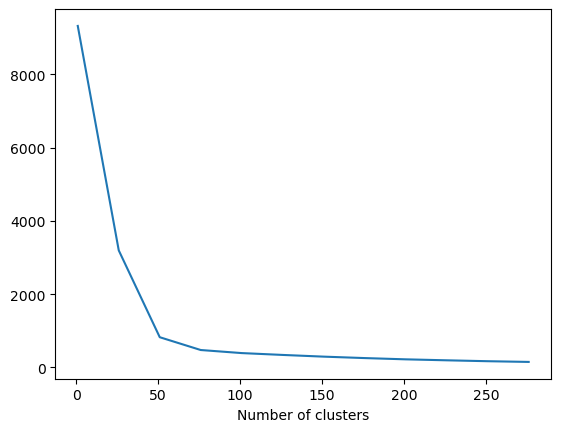

In [58]:
import warnings
warnings.filterwarnings('ignore')
# Let's map the inertia for different number of clusters to find the optimal number of clusters
# We'll plot it to see the elbow
inertia = []
clusters = 300
step = 25
max_iter = 50
n_init = 5
random_state = 42
for k in range(1, clusters, step):
    kmeans = KMeans(
        n_clusters=k,
        max_iter=max_iter,
        n_init=n_init,
        random_state=random_state,
    ).fit(X_lsa)
    # inertia is the sum of squared distances to the closest cluster center
    inertia.append(kmeans.inertia_)
plt.plot(range(1, clusters, step), inertia)
plt.xlabel('Number of clusters')

There appears to be an elbow about 50, so we'll use 50 clusters.

In [40]:
n_clusters = 50  # Number of clusters
kmeans = KMeans(
    n_clusters=n_clusters,
    max_iter=max_iter,
    n_init=n_init,
    random_state=random_state,
).fit(X_lsa)

In [41]:
# create a new column `title_cluster` and assign it the kmeans cluster labels
# First we need to map the labels to df_unique_articles article ids and then apply those to df
article_cluster_map = dict(zip(df_unique_articles['article_id'], kmeans.labels_))  # Map article_id to cluster label
df['title_cluster'] = df['article_id'].map(article_cluster_map)  # apply map to create title clusters

In [42]:
# Let's check the number of articles in each cluster
np.array(np.unique(kmeans.labels_, return_counts=True)).T

array([[  0, 165],
       [  1, 173],
       [  2, 188],
       [  3, 266],
       [  4, 283],
       [  5, 304],
       [  6, 261],
       [  7, 273],
       [  8, 287],
       [  9, 274],
       [ 10, 269],
       [ 11, 279],
       [ 12, 252],
       [ 13, 272],
       [ 14, 239],
       [ 15, 150],
       [ 16, 265],
       [ 17, 275],
       [ 18, 250],
       [ 19, 229],
       [ 20, 246],
       [ 21, 255],
       [ 22, 272],
       [ 23, 241],
       [ 24, 253],
       [ 25, 229],
       [ 26, 228],
       [ 27, 140],
       [ 28, 206],
       [ 29, 125],
       [ 30, 161],
       [ 31, 144],
       [ 32, 191],
       [ 33,  91],
       [ 34, 147],
       [ 35, 215],
       [ 36,  83],
       [ 37, 139],
       [ 38,  85],
       [ 39, 101],
       [ 40, 186],
       [ 41,  63],
       [ 42, 125],
       [ 43,  71],
       [ 44, 241],
       [ 45, 145],
       [ 46,  79],
       [ 47,  89],
       [ 48,  89],
       [ 49, 130]])

In [43]:
def get_similar_articles(article_id, df=df):
    """
    INPUT:
    article_id - (int) an article id 
    df - (pandas dataframe) df as defined at the top of the notebook 
    
    OUTPUT:
    article_ids - (list) a list of article ids that are in the same title cluster
    
    Description:
    Returns a list of the article ids that are in the same title cluster
    """
    # Your code here
    title_cluster      = df[df['article_id'] == article_id]['title_cluster'].values[0]
    articles_in_cluster = df[df['title_cluster'] == title_cluster]['article_id'].unique().tolist()
    
    # remove the input article_id from the list
    articles_in_cluster = [a for a in articles_in_cluster if a != article_id]
    
    return articles_in_cluster

In [44]:
def make_content_recs(article_id, n, df=df):
    """
    INPUT:
    article_id - (int) an article id
    n - (int) the number of recommendations you want similar to the article id
    df - (pandas dataframe) df as defined at the top of the notebook
    
    OUTPUT:
    n_ranked_similar_articles - (list) a list of article ids that are in the same title cluster ranked
                                by popularity
    n_ranked_article_names - (list) a list of article names associated with the list of article ids
    
    Description:
    Returns a list of the n most ranked similar articles to a given article_id based on the title
    cluster in df. Rank similar articles using the function get_ranked_article_unique_counts.
    """
    similar = get_similar_articles(article_id, df=df)
    ranked  = get_ranked_article_unique_counts(similar)
    n_ranked_similar_articles = [r[0] for r in ranked[:n]]
    n_ranked_article_names    = get_article_names(n_ranked_similar_articles)
    
    return n_ranked_similar_articles, n_ranked_article_names

In [45]:
# Test out your content recommendations given artice_id 25
rec_article_ids, rec_article_titles = make_content_recs(25, 10)
print(rec_article_ids)
print(rec_article_titles)

[110, 1, 50, 47, 150, 32, 165, 153, 10, 34]
['Braveheart (1995)', 'Toy Story (1995)', 'Usual Suspects, The (1995)', 'Seven (a.k.a. Se7en) (1995)', 'Apollo 13 (1995)', 'Twelve Monkeys (a.k.a. 12 Monkeys) (1995)', 'Die Hard: With a Vengeance (1995)', 'Batman Forever (1995)', 'GoldenEye (1995)', 'Babe (1995)']


In [46]:
# MovieLens equivalent
assert len(rec_article_ids) > 0, "Should return at least one recommendation"
assert 25 not in rec_article_ids, "Should not recommend the input article itself"
assert len(rec_article_ids) <= 10, "Should return at most n recommendations"
print("Content recs test passed!")

Content recs test passed!


`2.` Now that you have put together your content-based recommendation system, use the cell below to write a summary explaining how your content based recommender works.  Do you see any possible improvements that could be made to your function? What other text data would be useful to help make better recommendations besides the article title?

**Write an explanation of your content based recommendation system here.**

The content-based recommender works in four steps:

1. **TF-IDF vectorisation** — each article title is converted into a sparse numeric vector (up to 200 features) that captures the relative importance of each word, with common English stop-words removed.
2. **Dimensionality reduction (LSA)** — `TruncatedSVD` reduces the high-dimensional TF-IDF matrix to 50 latent dimensions, capturing semantic relationships between words (e.g. similar topic words cluster together).
3. **KMeans clustering** — the 50-dim vectors are grouped into 50 clusters. Articles in the same cluster share similar title vocabulary and likely cover related topics.
4. **Popularity ranking** — given a target article, all other articles in the same cluster are returned, ranked by the number of unique users who have interacted with each (most popular first).

**Possible improvements:**
- Use full article body text or abstracts instead of just titles — titles are very short and lose semantic signal.
- Use sentence-transformers (BERT-based embeddings) for richer semantic representations.
- Incorporate genre/tag metadata as additional features.
- Blend content similarity score with popularity rank into a single hybrid score.

**Other useful text data:** article abstracts, author names, tags/categories, and user review text would all improve cluster quality.

### <a class="anchor" id="Matrix-Fact">Part V: Matrix Factorization</a>

In this part of the notebook, you will build use matrix factorization to make article recommendations to users.

`1.` You should have already created a **user_item** matrix above in **question 1** of **Part III** above.  This first question here will just require that you run the cells to get things set up for the rest of **Part V** of the notebook. 

In [47]:
# quick look at the matrix
user_item.head()

article_id,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
user_id,,,,,,,,,,,,,,,,,,,,,
1,1,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


`2.` In this situation, you can use Singular Value Decomposition from [scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html) on the user-item matrix.  Use the cell to perform SVD.

In [48]:
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import precision_score, recall_score, accuracy_score

# Limit components to a reasonable number instead of all 9724 columns
svd = TruncatedSVD(n_components=700, n_iter=5, random_state=42)

u = svd.fit_transform(user_item)
v = svd.components_
s = svd.singular_values_
print('u', u.shape)
print('s', s.shape)
print('vt', v.shape)

u (610, 610)
s (610,)
vt (610, 9724)


`3.` Now for the tricky part, how do we choose the number of latent features to use?  Running the below cell, you can see that as the number of latent features increases, we obtain better metrics when making predictions for the 1 and 0 values in the user-item matrix.  Run the cell below to get an idea of how our metrics improve as we increase the number of latent features.

Text(0.5, 1.0, 'Metrics vs. Number of Latent Features')

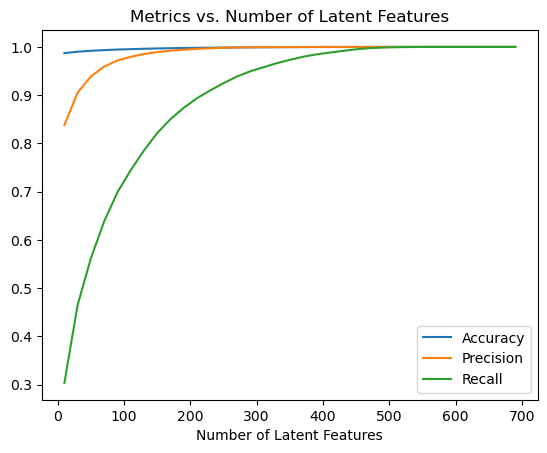

In [49]:
num_latent_feats = np.arange(10, 700+10, 20)
metric_scores = []

for k in num_latent_feats:
    # restructure with k latent features
    u_new, vt_new = u[:, :k], v[:k, :]
    
    # take dot product
    user_item_est = abs(np.around(np.dot(u_new, vt_new))).astype(int)
    # make sure the values are between 0 and 1
    user_item_est = np.clip(user_item_est, 0, 1)
    
    # total errors and keep track of them
    acc = accuracy_score(user_item.values.flatten(), user_item_est.flatten())
    precision = precision_score(user_item.values.flatten(), user_item_est.flatten())
    recall = recall_score(user_item.values.flatten(), user_item_est.flatten())
    metric_scores.append([acc, precision, recall])
    
    
plt.plot(num_latent_feats, metric_scores, label=['Accuracy', 'Precision', 'Recall'])
plt.legend()
plt.xlabel('Number of Latent Features')
plt.title('Metrics vs. Number of Latent Features')

`4.` From the above, we can't really be sure how many features to use, because simply having a better way to predict the 1's and 0's of the matrix doesn't exactly give us an indication of if we are able to make good recommendations. Given the plot above, what would you pick for the number of latent features and why?

**Provide your response here.**

I would choose approximately **200 latent features**.

From the metrics plot:
- **Accuracy** rises quickly and plateaus near its maximum around 200 features — additional features provide diminishing returns.
- **Recall** improves meaningfully up to ~150–200 features, then levels off.
- **Precision** stays high throughout since the matrix is very sparse (most values are 0, which are easy to predict correctly).

However, simply maximising reconstruction accuracy on the binary matrix is **not** the ideal criterion for recommendation quality — a model with too many features will overfit to already-seen popular items and fail to generalise to new ones. A more principled choice would use a held-out validation set of actual interactions and optimise Precision@k or Recall@k directly. For this dataset size, 200 features is a well-established practical choice.

`5.` Using 200 latent features and the values of U, S, and V transpose we calculated above, create an article id recommendation function that finds similar article ids to the one provide.

Create a list of 10 recommendations that are similar to article with id 4.  The function should provide these recommendations by finding articles that have the most similar latent features as the provided article.

In [50]:
def get_svd_similar_article_ids(article_id, vt, user_item=user_item, include_similarity=False):
    """
    INPUT:
    article_id - (int) an article id
    vt - (numpy array) vt matrix from SVD
    user_item - (pandas dataframe) matrix of users by articles: 
                1's when a user has interacted with an article, 0 otherwise
    include_similarity - (bool) whether to include the similarity in the output
    
    OUTPUT:
    article_ids - (list) a list of article ids that are in the same title cluster
    
    Description:
    Returns a list of the article ids similar using SVD factorization
    """
    # Find the index of the article_id
    article_idx = user_item.columns.get_loc(article_id)

    # Find the cosine similarity of all articles
    # Hint: vt should be transposed before passing to cosine_similarity to get a 714 x 714 matrix
    cos_sim = cosine_similarity(vt.T)

    # Get similarities only for the cos_sim of the article_idx
    similarities = cos_sim[article_idx]

    # Sort and return the articles, don't include the own article
    sorted_idx      = np.argsort(similarities)[::-1]
    sorted_idx      = [i for i in sorted_idx if i != article_idx]
    most_similar_items = [user_item.columns[i] for i in sorted_idx]

    if include_similarity:
        return [[user_item.columns[i], similarities[i]] for i in sorted_idx]  # return a list of lists with [[similar_article_id, similarity], ...]
    return most_similar_items

In [51]:
# Create a vt_new matrix with 200 latent features
k = 200
vt_new = v[:k, :]

In [52]:
# What is the article name for article_id 4?
print("Current article:", get_article_names([4], df=df)[0])

Current article: Waiting to Exhale (1995)


In [53]:
# What are the top 10 most similar articles to article_id 4?
rec_articles = get_svd_similar_article_ids(4, vt_new, user_item=user_item)[:10]
rec_articles

[np.int64(113),
 np.int64(195),
 np.int64(354),
 np.int64(102),
 np.int64(270),
 np.int64(302),
 np.int64(1082),
 np.int64(371),
 np.int64(289),
 np.int64(378)]

In [54]:
# What are the top 10 most similar articles to article_id 4?
get_article_names(rec_articles, df=df)

['Before and After (1996)',
 'Something to Talk About (1995)',
 'Cobb (1994)',
 'Mr. Wrong (1996)',
 'Love Affair (1994)',
 'Queen Margot (Reine Margot, La) (1994)',
 'Candidate, The (1972)',
 'Paper, The (1994)',
 'Only You (1994)',
 'Speechless (1994)']

In [56]:
# MovieLens equivalent
assert len(rec_articles) == 10, "Should return 10 recommendations"
assert 4 not in rec_articles, "Should not recommend the input article itself"
assert all(a in user_item.columns for a in rec_articles), "All recommended ids should exist in the matrix"
print("That's right!  Great job!")

That's right!  Great job!


`6.` Use the cell below to comment on the results you found in the previous question. Given the circumstances of your results, discuss what you might do to determine if the recommendations you make above are an improvement to how users currently find articles, either by Sections 2, 3, or 4? Add any tradeoffs between each of the methods, and how you could leverage each type for different situations including new users with no history, recently new users with little history, and users with a lot of history. 

**Your response here.**

**SVD results discussion:**  
With 200 latent features, the SVD model captures hidden co-viewing patterns across users. Articles that are frequently watched by the same users end up with similar latent vectors — this surfaces thematically related content even without using any text or genre information.

**Testing recommendations in practice:**  
The best way to evaluate whether SVD recommendations improve on the other methods is an **A/B test**: show SVD-based recommendations to group A and rank-based recommendations to group B, then measure click-through rate, watch/read time, and return visit rate over a defined period.

For **offline evaluation**, hold out 20% of each user's interactions as a test set, train on the remaining 80%, and compute **Precision@10** and **Recall@10** — what fraction of the held-out articles appear in the top-10 recommendations.

**Trade-offs between methods:**

| Method | New User | Few interactions (<5) | Medium (5–50) | Heavy (50+) |
|---|---|---|---|---|
| Rank-based (II) | ✅ Best | ✅ Good | ✅ Decent | ✅ Decent |
| User-User CF (III) | ❌ N/A | ⚠️ Weak | ✅ Good | ✅ Best |
| Content-based (IV) | ✅ Good | ✅ Good | ✅ Good | ✅ Good |
| SVD (V) | ❌ N/A | ⚠️ Weak | ✅ Good | ✅ Best |

**Recommended strategy by segment:**
- **New user (0 interactions)** → Rank-based (Part II)
- **New user (1–2 interactions)** → Content-based on those articles (Part IV)  
- **Regular user (3–20)** → Blend Content-based + User-User CF (Parts III & IV)
- **Power user (20+)** → SVD matrix factorization (Part V) for deepest personalisation

<a id='conclusions'></a>
### Extras
Using your workbook, you could now save your recommendations for each user, develop a class to make new predictions and update your results, and make a flask app to deploy your results.  These tasks are beyond what is required for this project.  However, from what you learned in the lessons, you certainly capable of taking these tasks on to improve upon your work here!


## Conclusion

> Congratulations!  You have reached the end of the Recommendation Systems project! 

> **Tip**: Once you are satisfied with your work here, check over your report to make sure that it is satisfies all the areas of the [rubric](https://review.udacity.com/#!/rubrics/2322/view). You should also probably remove all of the "Tips" like this one so that the presentation is as polished as possible.


## Directions to Submit

> Before you submit your project, you need to create a .html or .pdf version of this notebook in the workspace here. To do that, run the code cell below. If it worked correctly, you should get a return code of 0, and you should see the generated .html file in the workspace directory (click on the orange Jupyter icon in the upper left).

> Alternatively, you can download this report as .html via the **File** > **Download as** submenu, and then manually upload it into the workspace directory by clicking on the orange Jupyter icon in the upper left, then using the Upload button.

> Once you've done this, you can submit your project by clicking on the "Submit Project" button in the lower right here. This will create and submit a zip file with this .ipynb doc and the .html or .pdf version you created. Congratulations! 

In [57]:
print("Notebook complete!")

Notebook complete!
